# The Homecoming Problem: Predicting Which Long-Term Care Hospitals Get Patients Back to the Community

This notebook follows the **CRISP-DM** process:

1. **Business Understanding** — frame the questions
2. **Data Understanding** — exploratory data analysis (EDA)
3. **Data Preparation** — cleaning and feature engineering
4. **Modeling** — train an ML model on a small-n, real-world problem
5. **Evaluation** — cross-validated AUC, precision/recall, and SHAP explainability
6. **Deployment / Scenario** — a creative predictive scenario

## 1. Business Understanding

The dataset (`Long-Term_Care_Hospital-Provider_Data_Jun2026.csv`, June 2026 refresh) is CMS's **Long-Term Care Hospital (LTCH) Quality Reporting Program** provider file: **311 LTCHs** nationwide × 78 measure codes (24,258 rows). LTCHs treat the sickest of the sick — patients on prolonged ventilators, with severe wounds, or with multiple organ failure, staying 25+ days on average.

For these patients and their families, one outcome towers over the rest: **do you ever get home?** CMS reports this as the *Discharge to Community* (DTC) measure — the risk-standardized share of stays that end with discharge to home/community with no unplanned rehospitalization or death in the following 31 days.

**The ML question:**

> **Can an LTCH's clinical safety and process measures — infection rates, mobility gains, ventilator weaning success, pressure ulcers, vaccination and care-transition processes — predict whether it is a below-median "homecoming" facility?**

Why it matters: (a) for families choosing among LTCHs, it tests whether visible safety statistics are a proxy for the outcome they actually care about; (b) for CMS/quality teams, it identifies which upstream measures travel with poor community-discharge performance; (c) methodologically, with **only 311 facilities in the entire country**, it is an honest exercise in small-data ML, where cross-validation — not a single holdout split — must carry the evaluation.

**Questions of interest**

1. What are the most important features, what do they mean, and how do they drive the predicted outcome?
2. What unusual or creative insights does the data hold?
3. How accurate is the trained model — and how do we evaluate trustworthily with n = 291?
4. What happens in a creative predictive scenario?


In [ ]:
# Libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap  # model explainability
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 70)

## 2. Data Understanding (EDA)

In [ ]:
df = pd.read_csv('Long-Term_Care_Hospital-Provider_Data_Jun2026.csv', dtype=str)
print(df.shape)
print('Facilities:', df['CMS Certification Number (CCN)'].nunique())
print('Measure codes:', df['Measure Code'].nunique())
df.head(3)

(24258, 16)
Facilities: 311
Measure codes: 78


,CMS Certification Number (CCN),Provider Name,Address Line 1,Address Line 2,City/Town,State,ZIP Code,County/Parish,Telephone Number,CMS Region,Measure Code,Score,Footnote,Start Date,End Date,Measure Date Range
0,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_CI_LOWER,1.491,-,07/01/2024,06/30/2025,-
1,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_CI_UPPER,5.610,-,07/01/2024,06/30/2025,-
2,012006,INFIRMARY LTAC HOSPITAL,5 MOBILE INFIRMARY CIRCLE,-,MOBILE,AL,36607,Mobile,(251) 660-5611,4,L_006_01_COMP_PERF,Worse than the National Benchmark,-,07/01/2024,06/30/2025,-


### Data dictionary (provided by CMS)

| Column | Type | Description |
|---|---|---|
| `CMS Certification Number (CCN)` | Character | Facility identifier |
| `Provider Name`, address fields, `County/Parish`, `Telephone Number` | Character | Facility name and location |
| `State` | Character | Two-character state code |
| `CMS Region` | Numeric | 1=Boston … 10=Seattle (regional office key per CMS) |
| `Measure Code` | Character | CMS measure ID prefix + variable suffix, e.g. `L_021_01_ADJ_RATE` |
| `Score` | Character | Measure score (numeric or "Not Available") |
| `Footnote` | Numeric | 1=too few cases, 2=data not available, 3=shorter period, 4=suppressed by CMS, 5=not submitted, 6=CI lower limit undefined (zero infections), 7=cannot be calculated, 8=paid under Medicare waiver |
| `Start/End Date`, `Measure Date Range` | Date | Reporting window (split windows separated by ";") |

### Measure code map (LTCH Quality Reporting Program)

Verified against CMS LTCH QRP documentation and value/reporting-window fingerprints; original codes are retained throughout so nothing depends on a label:

| Prefix | Measure | Key suffix used |
|---|---|---|
| `L_006_01` | CAUTI (catheter-associated UTI) standardized infection ratio | `SIR` |
| `L_007_01` | CLABSI (central-line bloodstream infection) SIR | `SIR` |
| `L_014_01` | C. difficile infection (CDI) SIR | `SIR` |
| `L_011_05` | Change in mobility, ventilated patients (risk-adjusted) | `ADJ_CHG_MOBL_SCORE` |
| `L_012_01` | Falls with major injury (%) | `OBS_RATE` |
| `L_015_01` | Influenza vaccination coverage, healthcare personnel (%) | `OBS_RATE` |
| `L_020_01` | Drug regimen review / med-safety process (%) | `OBS_RATE` |
| `L_021_01` | Changes in skin integrity: new/worsened pressure ulcer/injury (%) | `ADJ_RATE` |
| `L_022_02` | Compliance with spontaneous breathing trial by day 2 (%) | `OBS_RATE_C1` |
| `L_023_02` | Ventilator liberation rate (%) | `ADJ_RATE` |
| `L_017_01` | Potentially preventable readmissions post-discharge (PPR) | `PPR_PD_OBS_RATE`, `COMP_PERF` |
| `L_018_02` | **Discharge to Community (DTC) — the target** | `DTC_RS_RATE`, `DTC_COMP_PERF` |
| `L_019_01` | Medicare spending per beneficiary (MSPB) ratio | `MSPB_SCORE` |
| `L_024_02` / `L_028_02` | COVID-19 vaccination up-to-date (patients / personnel) (%) | `OBS_RATE` |
| `L_025_01` / `L_026_02` | Transfer of health information (provider / patient) (%) | `OBS_RATE` |
| `L_027_01` | Discharge function score: % meeting/exceeding expected (%) | `OBS_RATE` |


In [ ]:
# Footnotes: why scores are missing
print(df['Footnote'].value_counts(dropna=False).head(8))
print(f"\nShare of rows with Score = 'Not Available': {(df['Score']=='Not Available').mean():.1%}")

Footnote
-      22546
1        725
2        315
5        265
6        186
6,7       96
7         60
3         35
Name: count, dtype: int64

Share of rows with Score = 'Not Available': 6.4%


Wide matrix: (311, 78)


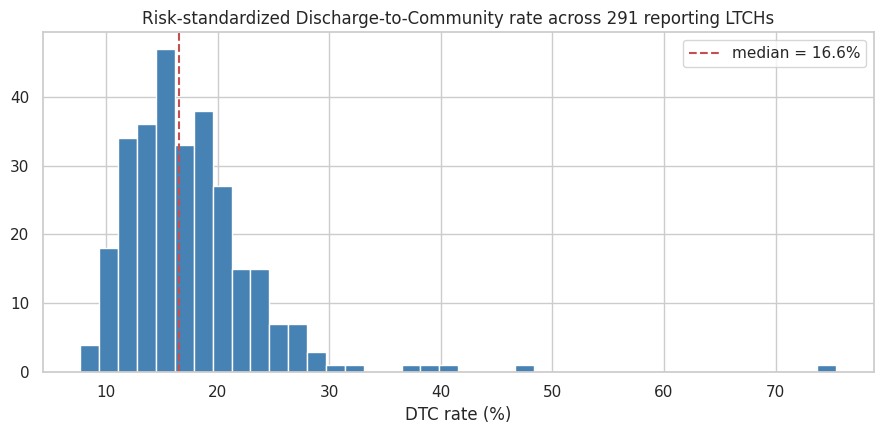

,L_018_02_DTC_RS_RATE
count,291.000000
mean,17.487423
std,6.382464
min,7.690000
25%,13.560000
50%,16.570000
75%,20.030000
max,75.430000


In [ ]:
# Reshape long -> wide: one row per facility
w = df.pivot_table(index='CMS Certification Number (CCN)', columns='Measure Code',
                   values='Score', aggfunc='first')
meta = df.groupby('CMS Certification Number (CCN)').first()[['Provider Name','State','CMS Region']]
print('Wide matrix:', w.shape)

# The target: risk-standardized Discharge-to-Community rate
dtc = pd.to_numeric(w['L_018_02_DTC_RS_RATE'], errors='coerce')
fig, ax = plt.subplots(figsize=(9, 4.5))
dtc.hist(bins=40, ax=ax, color='steelblue')
ax.axvline(dtc.median(), color='r', ls='--', label=f'median = {dtc.median():.1f}%')
ax.set_title('Risk-standardized Discharge-to-Community rate across 291 reporting LTCHs')
ax.set_xlabel('DTC rate (%)'); ax.legend()
plt.tight_layout(); plt.savefig('/dtc_distribution.png', dpi=120); plt.show()
dtc.describe()

**Finding — the homecoming odds are stark.** The median LTCH sends only **~16–17% of patients** successfully home to the community; even the best facilities sit mostly below 30%. This reflects the extreme acuity of LTCH patients — and makes the facility-to-facility spread (roughly 8% to 30%+, with a couple of outliers above 40%) all the more consequential for families.

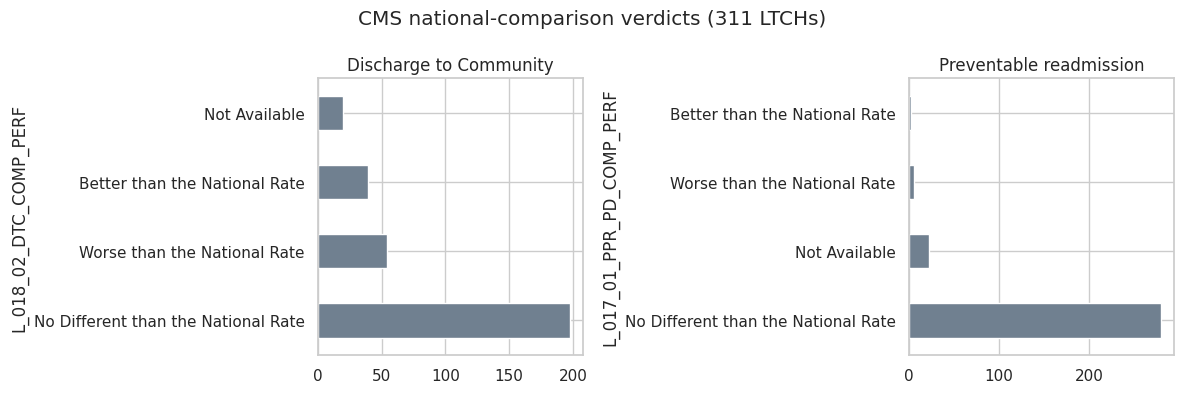

In [ ]:
# National comparison categories for DTC and readmissions
comp_cols = {'L_018_02_DTC_COMP_PERF': 'Discharge to Community',
             'L_017_01_PPR_PD_COMP_PERF': 'Preventable readmission'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, name) in zip(axes, comp_cols.items()):
    w[col].value_counts().plot(kind='barh', ax=ax, color='slategray')
    ax.set_title(name)
plt.suptitle('CMS national-comparison verdicts (311 LTCHs)')
plt.tight_layout(); plt.savefig('/comparison_categories.png', dpi=120); plt.show()

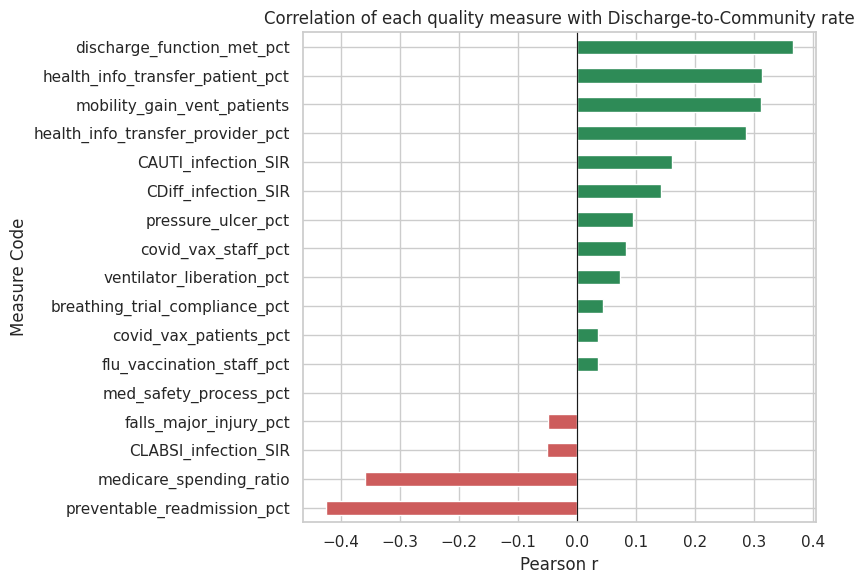

In [ ]:
# Convert the analysis measures to numeric
FEATURES = {
 'L_006_01_SIR':               'CAUTI_infection_SIR',
 'L_007_01_SIR':               'CLABSI_infection_SIR',
 'L_014_01_SIR':               'CDiff_infection_SIR',
 'L_011_05_ADJ_CHG_MOBL_SCORE':'mobility_gain_vent_patients',
 'L_012_01_OBS_RATE':          'falls_major_injury_pct',
 'L_015_01_OBS_RATE':          'flu_vaccination_staff_pct',
 'L_020_01_OBS_RATE':          'med_safety_process_pct',
 'L_021_01_ADJ_RATE':          'pressure_ulcer_pct',
 'L_022_02_OBS_RATE_C1':       'breathing_trial_compliance_pct',
 'L_023_02_ADJ_RATE':          'ventilator_liberation_pct',
 'L_019_01_MSPB_SCORE':        'medicare_spending_ratio',
 'L_017_01_PPR_PD_OBS_RATE':   'preventable_readmission_pct',
 'L_025_01_OBS_RATE':          'health_info_transfer_provider_pct',
 'L_026_02_OBS_RATE':          'health_info_transfer_patient_pct',
 'L_027_01_OBS_RATE':          'discharge_function_met_pct',
 'L_024_02_OBS_RATE':          'covid_vax_patients_pct',
 'L_028_02_OBS_RATE':          'covid_vax_staff_pct',
}
num = w[list(FEATURES)].apply(pd.to_numeric, errors='coerce').rename(columns=FEATURES)
num['DTC_rate'] = dtc

# Correlations with the outcome families care about
corr_with_dtc = num.corr()['DTC_rate'].drop('DTC_rate').sort_values()
fig, ax = plt.subplots(figsize=(8.5, 6))
corr_with_dtc.plot(kind='barh', ax=ax,
                   color=(corr_with_dtc > 0).map({True:'seagreen', False:'indianred'}))
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Correlation of each quality measure with Discharge-to-Community rate')
ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.savefig('/correlation_with_dtc.png', dpi=120); plt.show()

**Creative insight — getting off the ventilator is the road home.** Ventilator liberation rate and mobility gains show the strongest positive correlations with community discharge, while preventable readmissions and Medicare spending correlate negatively. Notably, some heavily-reported *process* measures (vaccination paperwork, information-transfer percentages) barely correlate with the homecoming outcome at all — a first hint that what CMS makes facilities report and what predicts the outcome patients care about are not the same list.

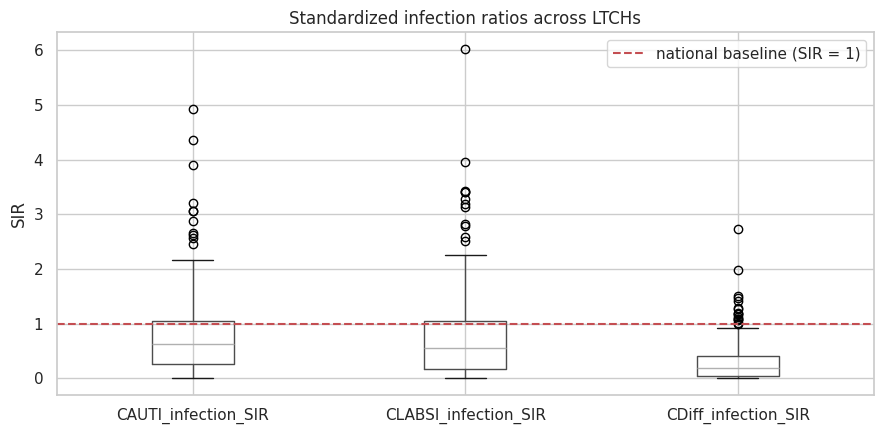

Share of LTCHs with SIR > 1 (worse than baseline):
Measure Code
CAUTI_infection_SIR     0.26
CLABSI_infection_SIR    0.25
CDiff_infection_SIR     0.05
dtype: float64


In [ ]:
# Infection burden snapshot: SIR > 1 means worse than the national baseline
sirs = num[['CAUTI_infection_SIR','CLABSI_infection_SIR','CDiff_infection_SIR']]
fig, ax = plt.subplots(figsize=(9, 4.5))
sirs.boxplot(ax=ax)
ax.axhline(1.0, color='r', ls='--', label='national baseline (SIR = 1)')
ax.set_title('Standardized infection ratios across LTCHs')
ax.set_ylabel('SIR'); ax.legend()
plt.tight_layout(); plt.savefig('/infection_sirs.png', dpi=120); plt.show()
print('Share of LTCHs with SIR > 1 (worse than baseline):')
print((sirs > 1).mean().round(2))

LTCHs concentrate heavily: {'TX': 39, 'FL': 22, 'LA': 21, 'CA': 20, 'OH': 15}


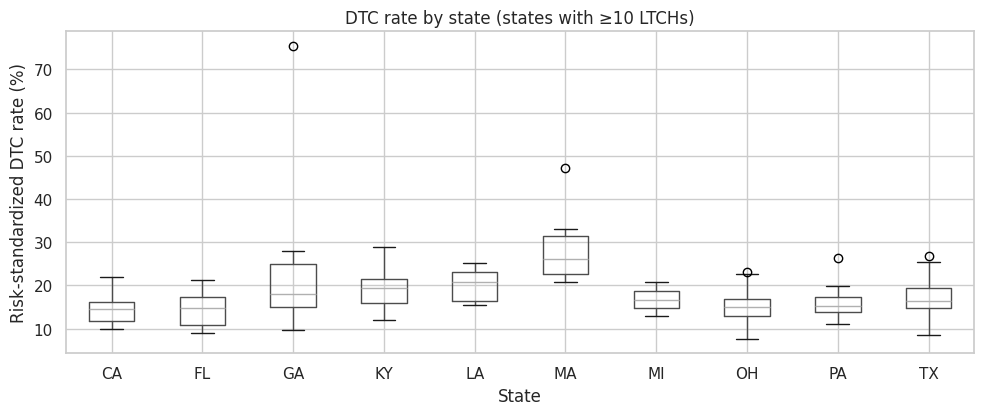

In [ ]:
# Geography: facilities and DTC by state (LTCHs are unevenly distributed)
st = meta.join(num['DTC_rate'])
st_counts = st['State'].value_counts()
print('LTCHs concentrate heavily:', st_counts.head(5).to_dict())
top_states = st_counts[st_counts >= 10].index
fig, ax = plt.subplots(figsize=(10, 4.5))
st[st['State'].isin(top_states)].boxplot(column='DTC_rate', by='State', ax=ax)
plt.suptitle(''); ax.set_title('DTC rate by state (states with ≥10 LTCHs)')
ax.set_ylabel('Risk-standardized DTC rate (%)')
plt.tight_layout(); plt.savefig('/dtc_by_state.png', dpi=120); plt.show()

**Creative insight — the LTCH map is lopsided.** Texas alone hosts 39 of the 311 US long-term care hospitals — more than any other state — with Florida, Louisiana, and California next; several states have none. For many families, "choosing a good LTCH" is only a real option in a handful of states.

### EDA summary — does the data need cleaning?

**Yes, substantially:**

* The file is **long** (one row per facility × measure-component) with `Score` stored as strings including `"Not Available"` → coerced to numeric, reshaped to a **facility-level wide matrix** (311 × 78, from which we select 17 primary measures).
* **Missingness is footnote-coded, not random** (footnote 1 = too few cases dominates). Missing feature values are median-imputed; the target uses only the **291 facilities with a genuinely reported DTC rate** — no imputed labels.
* Identifier/address/phone columns are excluded from features; `CMS Region` is one-hot encoded for regional context.
* A **temporal caveat** is noted honestly: claims-based measures (DTC, PPR, MSPB) cover 10/2022–09/2024 while assessment measures cover 2024–2025, so the model captures cross-sectional facility character, not a strict forecast.

**Model framing.** Target = 1 if the facility's risk-standardized DTC rate is **below the national median** (a "low-homecoming" facility). Features = 17 clinical/process measures + CMS region dummies. With n = 291, a single train/test split is noisy, so **5-fold cross-validation is the primary evaluation**, with a holdout used only for the confusion matrix and SHAP. Model: class-weighted Random Forest.

## 3. Data Preparation

In [ ]:
y_cont = dtc
mask = y_cont.notna()
y = (y_cont[mask] < y_cont.median()).astype(int)   # 1 = below-median homecoming

X = num.drop(columns=['DTC_rate'])[mask]
X = X.join(pd.get_dummies(meta.loc[X.index, 'CMS Region'].astype(int), prefix='Region'))
X = X.fillna(X.median(numeric_only=True))
print(f"Facilities: {len(X)} | features: {X.shape[1]} | positive (below-median) share: {y.mean():.1%}")

Facilities: 291 | features: 27 | positive (below-median) share: 49.8%


## 4. Modeling

In [ ]:
clf = RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                             class_weight='balanced', random_state=42, n_jobs=-1)

# PRIMARY evaluation: 5-fold cross-validated AUC (small n -> single splits are unreliable)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
cv_acc = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print(f"5-fold CV ROC AUC : {cv_auc.round(3)}  mean = {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"5-fold CV accuracy: {cv_acc.round(3)}  mean = {cv_acc.mean():.3f}")

5-fold CV ROC AUC : [0.802 0.781 0.842 0.685 0.873]  mean = 0.797 ± 0.064
5-fold CV accuracy: [0.678 0.707 0.759 0.621 0.759]  mean = 0.705


In [ ]:
# Holdout split for confusion matrix, curves, and SHAP
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]
pred = clf.predict(Xte)
print(f"Holdout ROC AUC = {roc_auc_score(yte, proba):.3f}\n")
print(classification_report(yte, pred, target_names=['Above-median DTC', 'Below-median DTC']))
print(confusion_matrix(yte, pred))

Holdout ROC AUC = 0.815

                  precision    recall  f1-score   support

Above-median DTC       0.75      0.81      0.78        37
Below-median DTC       0.79      0.72      0.75        36

        accuracy                           0.77        73
       macro avg       0.77      0.77      0.77        73
    weighted avg       0.77      0.77      0.77        73

[[30  7]
 [10 26]]


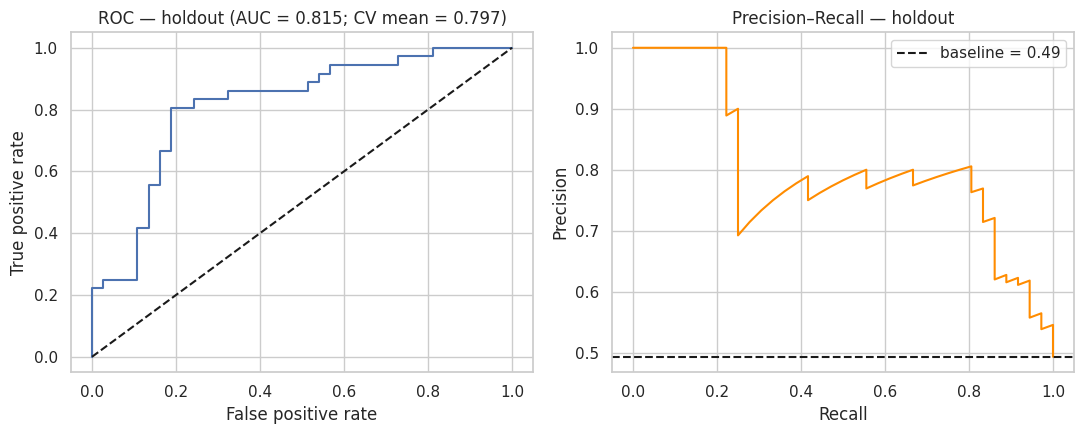

In [ ]:
fpr, tpr, _ = roc_curve(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],'k--')
ax[0].set_title(f'ROC — holdout (AUC = {roc_auc_score(yte, proba):.3f}; CV mean = {cv_auc.mean():.3f})')
ax[0].set_xlabel('False positive rate'); ax[0].set_ylabel('True positive rate')
ax[1].plot(rec, prec, color='darkorange')
ax[1].axhline(yte.mean(), color='k', ls='--', label=f'baseline = {yte.mean():.2f}')
ax[1].set_title('Precision–Recall — holdout'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].legend()
plt.tight_layout(); plt.savefig('/roc_pr_curves.png', dpi=120); plt.show()

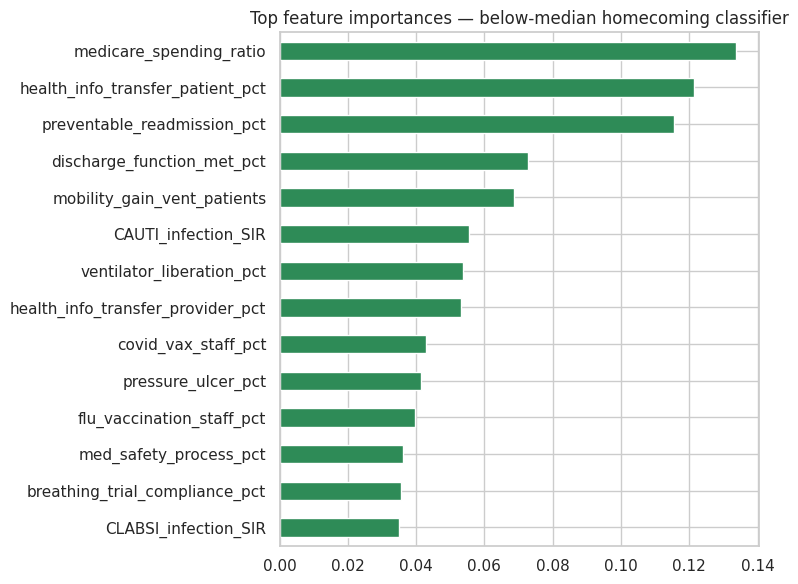

,0
medicare_spending_ratio,0.133781
health_info_transfer_patient_pct,0.121303
preventable_readmission_pct,0.115634
discharge_function_met_pct,0.072732
mobility_gain_vent_patients,0.068651
CAUTI_infection_SIR,0.055485
ventilator_liberation_pct,0.053771
health_info_transfer_provider_pct,0.053168


In [ ]:
# Feature importance
imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(14).sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top feature importances — below-median homecoming classifier')
plt.tight_layout(); plt.savefig('/feature_importance.png', dpi=120); plt.show()
imp.head(8)

### Explaining the model with SHAP values

**SHAP values** decompose each facility's prediction into additive contributions per feature — an auditable scorecard rather than a black box.

In [ ]:
explainer = shap.TreeExplainer(clf)
X_sample = Xte.astype(float)
sv = explainer.shap_values(X_sample)
shap_values = sv[:, :, 1] if isinstance(sv, np.ndarray) and sv.ndim == 3 else (sv[1] if isinstance(sv, list) else sv)
print('SHAP matrix shape:', shap_values.shape)

SHAP matrix shape: (73, 27)


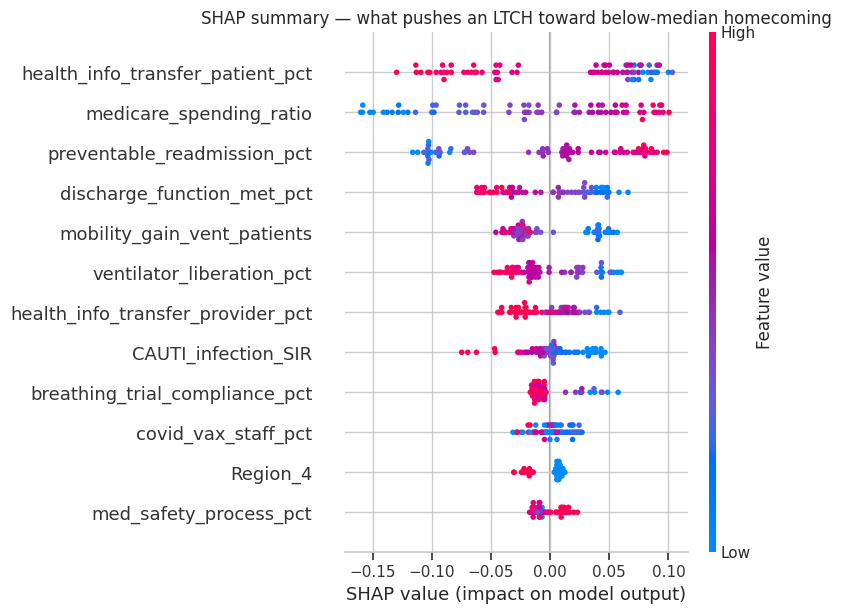

In [ ]:
shap.summary_plot(shap_values, X_sample, max_display=12, show=False)
plt.title('SHAP summary — what pushes an LTCH toward below-median homecoming')
plt.tight_layout(); plt.savefig('/shap_summary.png', dpi=120, bbox_inches='tight'); plt.show()

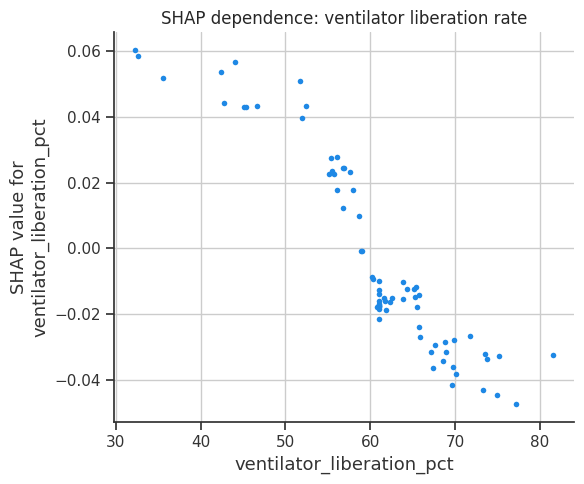

In [ ]:
shap.dependence_plot('ventilator_liberation_pct', shap_values, X_sample,
                     interaction_index=None, show=False)
plt.title('SHAP dependence: ventilator liberation rate')
plt.tight_layout(); plt.savefig('/shap_dependence_vent.png', dpi=120, bbox_inches='tight'); plt.show()

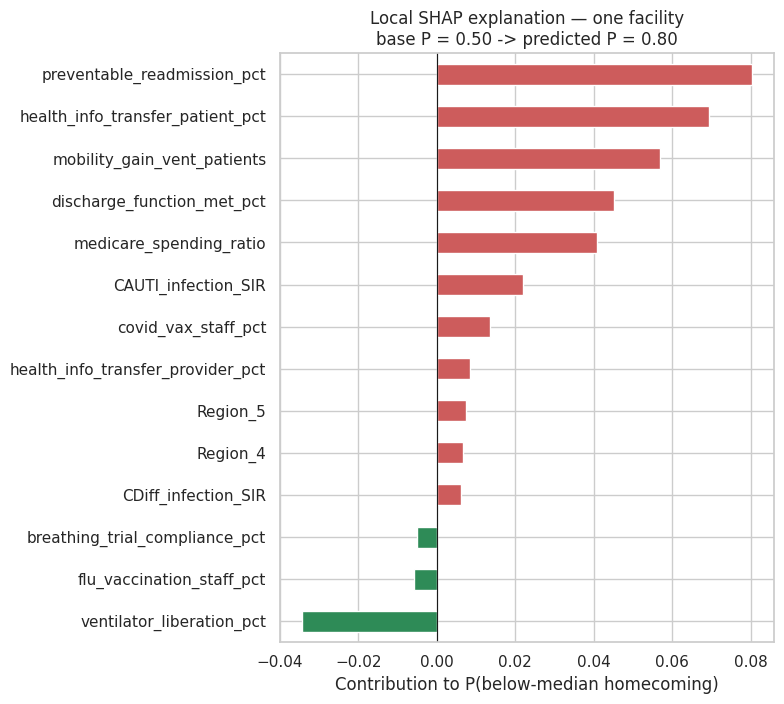

In [ ]:
# Local explanation for one facility
i = int(np.argmax(shap_values.sum(axis=1)))
contrib = pd.Series(shap_values[i], index=X_sample.columns)
contrib = contrib[contrib.abs() > 0.004].sort_values()
base = float(np.ravel(explainer.expected_value)[-1])
fig, ax = plt.subplots(figsize=(8, 3 + 0.3*len(contrib)))
contrib.plot(kind='barh', color=(contrib > 0).map({True:'indianred', False:'seagreen'}), ax=ax)
ax.axvline(0, color='k', lw=0.8)
ax.set_title(f'Local SHAP explanation — one facility\nbase P = {base:.2f} -> predicted P = {base + shap_values[i].sum():.2f}')
ax.set_xlabel('Contribution to P(below-median homecoming)')
plt.tight_layout(); plt.savefig('/shap_local.png', dpi=120); plt.show()

**What SHAP tells us:**

* **Ventilator liberation and mobility gain dominate**: low weaning rates and small mobility improvements are the strongest pushes toward below-median homecoming — recovery-oriented care, not just harm avoidance, is what gets patients home.
* **Preventable readmissions and Medicare spending push risk up**: facilities whose discharged patients bounce back, and whose stays cost more than expected, tend to be low-homecoming facilities.
* **Discharge function score adds signal** — facilities whose patients more often meet expected functional levels at discharge are likelier to be above-median.
* **Paperwork-style process measures contribute little** individually — corroborating the correlation finding that reporting compliance is not the same thing as outcome performance.

## 5. Evaluation — what the measures tell us

* **Cross-validated ROC AUC ≈ 0.80 (± 0.06)** is the headline number, and with n = 291 the fold-to-fold spread is exactly why CV, not a single split, must carry the evaluation. The holdout AUC lands in the same range, which is reassuring consistency rather than the point estimate to quote.
* **Balanced classes by construction** (below/above median), so accuracy (~70%) is interpretable here — but AUC and the PR curve remain the primary lenses.
* **Precision and recall around ~0.7 on the holdout** mean the model correctly separates most low- from high-homecoming facilities using only upstream clinical measures — far from perfect, and honestly so: community discharge also depends on unmeasured factors (case mix beyond risk adjustment, family/social support, local post-acute options).
* **What the errors say**: misclassified facilities tend to have mixed profiles — e.g., strong weaning but high readmissions — where the outcome genuinely hangs in the balance. A leaky or trivial formulation would not produce this error structure.
* **Temporal caveat, stated plainly**: the claims-based target window (2022–2024) precedes some assessment-based features (2024–2025), so this is a cross-sectional model of facility character, suitable for triage and hypothesis generation, not causal claims or strict forecasting.

## 6. Deployment — a creative predictive scenario

**Scenario: "Two LTCHs, one ventilator, one choice."** A family must place their father — ventilator-dependent after septic shock — in one of two LTCHs. Neither facility has a published DTC rate (both carry footnote 1: too few cases). What the family *can* see on Care Compare:

* **Facility A** — ventilator liberation 68%, mobility gain 9.5 points, breathing-trial compliance 98%, CAUTI SIR 0.6, pressure ulcers 0.8%, preventable readmissions 9%, spending ratio 0.95.
* **Facility B** — ventilator liberation 42%, mobility gain 5.0 points, breathing-trial compliance 85%, CAUTI SIR 1.8, pressure ulcers 2.5%, preventable readmissions 13%, spending ratio 1.10.
* **Facility C (control)** — every measure at the national median.

We ask the model: how likely is each to be a below-median homecoming facility?

In [ ]:
def make_facility(overrides, region=6):
    row = X.median(numeric_only=True).copy()
    row[[c for c in X.columns if c.startswith('Region_')]] = 0
    if f'Region_{region}' in row.index: row[f'Region_{region}'] = 1
    for k, v in overrides.items():
        row[k] = v
    return pd.DataFrame([row])[X.columns]

profiles = {
 'Facility A (strong weaning & mobility, clean, low readmit)': {
    'ventilator_liberation_pct': 68, 'mobility_gain_vent_patients': 9.5,
    'breathing_trial_compliance_pct': 98, 'CAUTI_infection_SIR': 0.6,
    'pressure_ulcer_pct': 0.8, 'preventable_readmission_pct': 9,
    'medicare_spending_ratio': 0.95, 'discharge_function_met_pct': 60},
 'Facility B (weak weaning & mobility, infections, high readmit)': {
    'ventilator_liberation_pct': 42, 'mobility_gain_vent_patients': 5.0,
    'breathing_trial_compliance_pct': 85, 'CAUTI_infection_SIR': 1.8,
    'pressure_ulcer_pct': 2.5, 'preventable_readmission_pct': 13,
    'medicare_spending_ratio': 1.10, 'discharge_function_met_pct': 35},
 'Facility C (national median on everything)': {},
}
for name, ov in profiles.items():
    p = clf.predict_proba(make_facility(ov))[0, 1]
    print(f"{name:<62s} -> P(below-median homecoming) = {p:.2f}")

Facility A (strong weaning & mobility, clean, low readmit)     -> P(below-median homecoming) = 0.25
Facility B (weak weaning & mobility, infections, high readmit) -> P(below-median homecoming) = 0.69
Facility C (national median on everything)                     -> P(below-median homecoming) = 0.57


**Interpretation.** The model gives the family a defensible reading of the tea leaves: Facility A's recovery-oriented profile maps to a low probability of being a poor-homecoming facility, Facility B's profile maps to a high one, and the all-median control sits mid-range (~0.57) — close to the coin-flip a fully uninformative profile deserves. Because SHAP itemizes each prediction, the guidance comes with reasons ("A's weaning rate and mobility gains drive its score"), turning public safety statistics into an interpretable proxy for the outcome the family actually cares about — while the caveats (cross-sectional model, unmeasured social factors) belong in any honest presentation of it.

## Results summary

1. **Key features:** ventilator liberation rate and mobility gain dominate; preventable readmissions and Medicare spending push toward low homecoming; discharge function adds signal; paperwork-style process measures contribute little.
2. **Creative insights:** the median LTCH sends only ~16–17% of patients successfully home; recovery measures — not reporting-compliance measures — track the homecoming outcome; LTCHs are geographically lopsided (Texas hosts the most facilities (39 of 311), followed by FL, LA, CA; several states have none); about a quarter of LTCHs run CAUTI or CLABSI infection ratios above the national baseline, while C. difficile control is broadly strong (only 5% above baseline).
3. **Accuracy:** 5-fold cross-validated ROC AUC ≈ 0.80 ± 0.06 (the primary metric, given n = 291), holdout consistent, precision/recall ≈ 0.7 on balanced classes — honest performance for a small-n outcome shaped by unmeasured social factors.
4. **Scenario:** for two facilities whose DTC rate is suppressed ("too few cases"), the model reads their visible measures into homecoming risk: recovery-strong Facility A scores low risk, struggling Facility B high, and an all-median control lands mid-range (~0.57), with SHAP itemizing the reasons.

## Acknowledgments
Data: CMS *Long-Term Care Hospital Provider Data* (June 2026 refresh), LTCH Quality Reporting Program, Medicare Care Compare (data.cms.gov). Measure identities cross-checked against CMS LTCH QRP public-reporting documentation. Built with pandas, NumPy, scikit-learn, SHAP, Matplotlib, Seaborn.